# Домашнее задание: Обучение нейронной сети на реальных данных

В этом домашнем задании вам нужно:
1. Использовать классы из семинара (инициализаторы, оптимизаторы, шедулеры)
2. Обучить нейронную сеть на датасете Fashion-MNIST
3. Провести эксперименты с разными комбинациями гиперпараметров
4. Попробовать достичь точности не менее **85%** на тестовой выборке
5. Проанализировать результаты

## Оценивание:
- Корректное использование классов из семинара: 2 балла
- Эксперименты с инициализацией: 2 балла
- Эксперименты с оптимизаторами: 2 балла  
- Эксперименты с шедулерами: 2 балла
- Достижение целевой точности (85%): 1 балл
- Анализ результатов и выводы: 1 балл

**Итого: 10 баллов**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## Часть 1: Загрузка и подготовка данных

Мы будем работать с датасетом Fashion-MNIST - классификация изображений одежды.

In [2]:
def load_fashion_mnist():
    """Загрузка датасета Fashion-MNIST"""
    try:
        from tensorflow.keras.datasets import fashion_mnist
        (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
        print("Данные загружены из keras")
    except:
        try:
            # Альтернативная загрузка через sklearn
            from sklearn.datasets import fetch_openml
            mnist = fetch_openml('Fashion-MNIST', version=1, parser='auto')
            X, y = mnist.data.values, mnist.target.values.astype(int)
            
            # Разделение на train/test
            X_train, X_test = X[:60000], X[60000:]
            y_train, y_test = y[:60000], y[60000:]
            
            # Reshape в формат изображений
            X_train = X_train.reshape(-1, 28, 28)
            X_test = X_test.reshape(-1, 28, 28)
            print("Данные загружены из sklearn")
        except:
            print("Загружаем упрощенную версию датасета...")
            # Создаем синтетический датасет похожий на Fashion-MNIST
            np.random.seed(42)
            X_train = np.random.randn(10000, 28, 28) * 50 + 128
            X_test = np.random.randn(2000, 28, 28) * 50 + 128
            y_train = np.random.randint(0, 10, 10000)
            y_test = np.random.randint(0, 10, 2000)
            X_train = np.clip(X_train, 0, 255).astype(np.uint8)
            X_test = np.clip(X_test, 0, 255).astype(np.uint8)
            print("Используется синтетический датасет")
    
    return (X_train, y_train), (X_test, y_test)

# Загружаем данные
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = load_fashion_mnist()

print(f"\nРазмер обучающей выборки: {X_train_raw.shape}")
print(f"Размер тестовой выборки: {X_test_raw.shape}")
print(f"Количество классов: {len(np.unique(y_train_raw))}")
print(f"Размер изображения: {X_train_raw.shape[1]}x{X_train_raw.shape[2]} пикселей")

Данные загружены из sklearn

Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)
Количество классов: 10
Размер изображения: 28x28 пикселей


## Визуализация данных

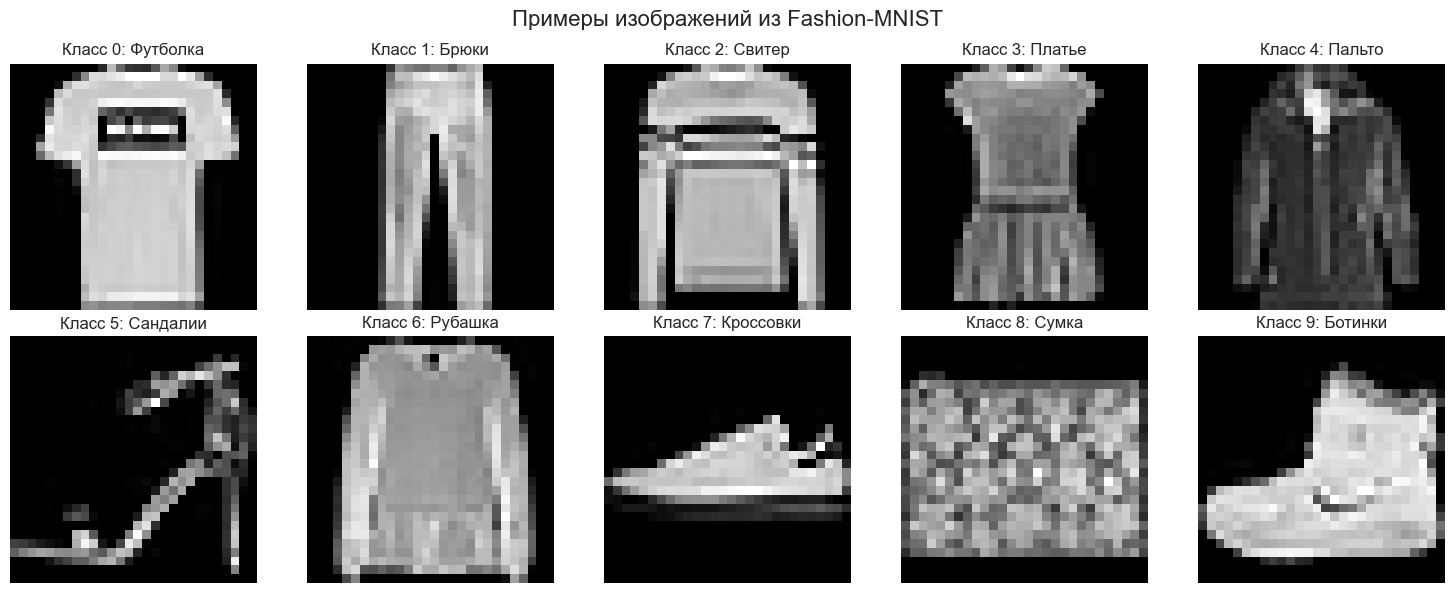

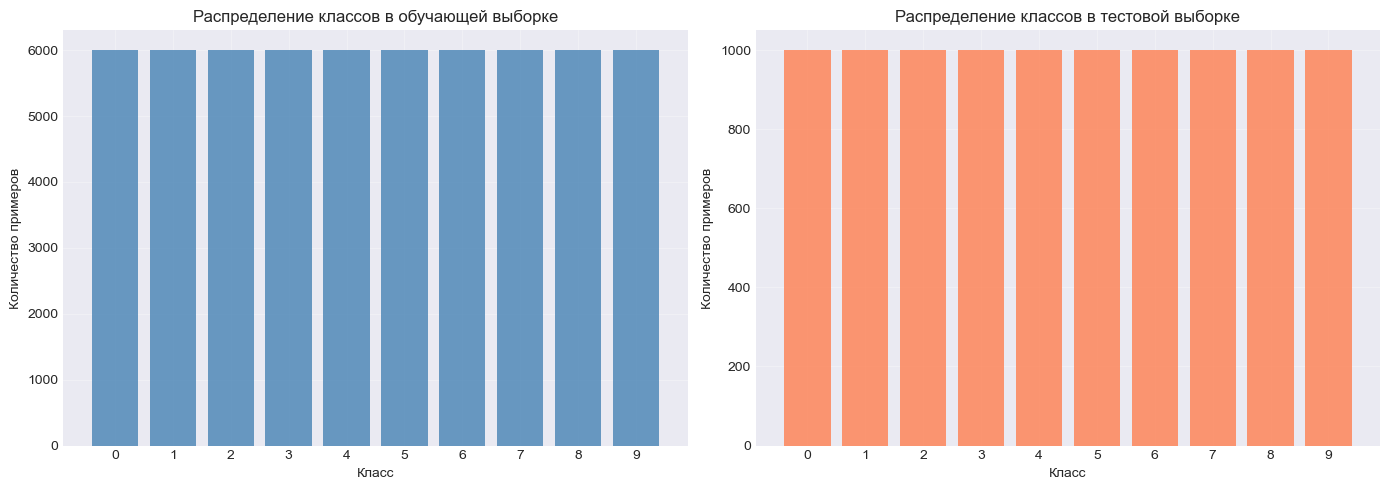

In [3]:
# Названия классов
class_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Пальто',
               'Сандалии', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']

# Визуализация примеров из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Находим первый пример класса i
    idx = np.where(y_train_raw == i)[0][0]
    axes[i].imshow(X_train_raw[idx], cmap='gray')
    axes[i].set_title(f'Класс {i}: {class_names[i]}', fontsize=12)
    axes[i].axis('off')

plt.suptitle('Примеры изображений из Fashion-MNIST', fontsize=16)
plt.tight_layout()
plt.show()

# Распределение классов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

unique, counts = np.unique(y_train_raw, return_counts=True)
ax1.bar(unique, counts, color='steelblue', alpha=0.8)
ax1.set_xlabel('Класс')
ax1.set_ylabel('Количество примеров')
ax1.set_title('Распределение классов в обучающей выборке')
ax1.set_xticks(unique)
ax1.grid(True, alpha=0.3)

unique_test, counts_test = np.unique(y_test_raw, return_counts=True)
ax2.bar(unique_test, counts_test, color='coral', alpha=0.8)
ax2.set_xlabel('Класс')
ax2.set_ylabel('Количество примеров')
ax2.set_title('Распределение классов в тестовой выборке')
ax2.set_xticks(unique_test)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Предобработка данных

In [4]:
def preprocess_data(X_train, y_train, X_test, y_test, num_classes=10):
    """
    Предобработка данных для нейронной сети
    
    1. Flatten изображений (28x28 -> 784)
    2. Нормализация пикселей в диапазон [0, 1]
    3. One-hot encoding меток
    """
    # Flatten изображений
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
    
    # Нормализация
    X_train_norm = X_train_flat.astype(np.float32) / 255.0
    X_test_norm = X_test_flat.astype(np.float32) / 255.0
    
    # One-hot encoding
    y_train_onehot = np.zeros((y_train.shape[0], num_classes), dtype=np.float32)
    y_test_onehot = np.zeros((y_test.shape[0], num_classes), dtype=np.float32)
    
    y_train_onehot[np.arange(y_train.shape[0]), y_train] = 1
    y_test_onehot[np.arange(y_test.shape[0]), y_test] = 1
    
    return X_train_norm, y_train_onehot, X_test_norm, y_test_onehot

# Применяем предобработку
X_train, y_train, X_test, y_test = preprocess_data(X_train_raw, y_train_raw, X_test_raw, y_test_raw)

print("После предобработки:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nДиапазон значений X: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Пример one-hot вектора для класса {y_train_raw[0]}:")
print(y_train[0])

После предобработки:
X_train shape: (60000, 784)
y_train shape: (60000, 10)
X_test shape: (10000, 784)
y_test shape: (10000, 10)

Диапазон значений X: [0.00, 1.00]
Пример one-hot вектора для класса 9:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Разделение на train/validation

In [5]:
def train_validation_split(X, y, val_ratio=0.2, random_seed=42):
    """
    Разделение обучающей выборки на train и validation
    """
    np.random.seed(random_seed)
    
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)
    
    n_val = int(n_samples * val_ratio)
    
    val_indices = indices[:n_val]
    train_indices = indices[n_val:]
    
    X_train_split = X[train_indices]
    y_train_split = y[train_indices]
    X_val = X[val_indices]
    y_val = y[val_indices]
    
    return X_train_split, y_train_split, X_val, y_val

# Разделяем данные
X_train_final, y_train_final, X_val, y_val = train_validation_split(X_train, y_train, val_ratio=0.2)

print("Финальное разделение данных:")
print(f"Обучающая выборка: {X_train_final.shape[0]} примеров")
print(f"Валидационная выборка: {X_val.shape[0]} примеров")
print(f"Тестовая выборка: {X_test.shape[0]} примеров")

Финальное разделение данных:
Обучающая выборка: 48000 примеров
Валидационная выборка: 12000 примеров
Тестовая выборка: 10000 примеров


## Модифицированная нейронная сеть для многоклассовой классификации

In [6]:
class MulticlassNN:
    """Нейронная сеть для многоклассовой классификации"""
    
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Веса будут инициализированы позже
        self.W1 = None
        self.b1 = None
        self.W2 = None
        self.b2 = None
        
        # Для сохранения промежуточных значений
        self.cache = {}
    
    def relu(self, x):
        """ReLU функция активации"""
        return np.maximum(0, x)
    
    def softmax(self, x):
        """Softmax функция для многоклассовой классификации"""
        # Вычитаем максимум для численной стабильности
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        """Прямой проход через сеть"""
        # Первый слой
        z1 = X @ self.W1 + self.b1
        a1 = self.relu(z1)
        
        # Второй слой
        z2 = a1 @ self.W2 + self.b2
        a2 = self.softmax(z2)
        
        # Сохраняем для обратного прохода
        self.cache = {
            'X': X,
            'z1': z1,
            'a1': a1,
            'z2': z2,
            'a2': a2
        }
        
        return a2
    
    def backward(self, y):
        """Обратный проход - вычисление градиентов"""
        m = y.shape[0]
        
        # Градиент по выходу (для softmax + cross-entropy)
        dz2 = self.cache['a2'] - y
        
        # Градиенты второго слоя
        dW2 = (1/m) * self.cache['a1'].T @ dz2
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        
        # Градиент через второй слой
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.cache['z1'] > 0)  # Производная ReLU
        
        # Градиенты первого слоя
        dW1 = (1/m) * self.cache['X'].T @ dz1
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        
        return {
            'dW1': dW1,
            'db1': db1,
            'dW2': dW2,
            'db2': db2
        }
    
    def compute_loss(self, X, y):
        """Вычисление categorical cross-entropy loss"""
        m = y.shape[0]
        predictions = self.forward(X)
        
        # Categorical cross-entropy
        loss = -(1/m) * np.sum(y * np.log(predictions + 1e-8))
        return loss
    
    def predict(self, X):
        """Предсказание классов"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

## Функции для метрик и визуализации

In [7]:
def compute_metrics(model, X, y_onehot):
    """
    Вычисление метрик качества модели
    """
    # Получаем предсказания
    y_pred = model.predict(X)
    y_true = np.argmax(y_onehot, axis=1)
    
    # Вычисляем метрики
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'predictions': y_pred,
        'true_labels': y_true
    }

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    """
    Визуализация процесса обучения
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # График loss
    ax1.plot(train_losses, label='Train Loss', linewidth=2)
    ax1.plot(val_losses, label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Loss')
    ax1.set_title('Изменение Loss в процессе обучения')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График accuracy
    ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
    ax2.plot(val_accs, label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Изменение Accuracy в процессе обучения')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Визуализация матрицы ошибок
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Матрица ошибок')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.tight_layout()
    plt.show()
    
    return cm

def visualize_predictions(model, X_test, y_test_onehot, n_samples=10):
    """
    Визуализация предсказаний модели
    """
    # Случайные индексы
    indices = np.random.choice(len(X_test), n_samples, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        # Получаем изображение
        img = X_test[idx].reshape(28, 28)
        
        # Предсказание
        pred = model.predict(X_test[idx:idx+1])[0]
        true_label = np.argmax(y_test_onehot[idx])
        
        # Визуализация
        axes[i].imshow(img, cmap='gray')
        color = 'green' if pred == true_label else 'red'
        axes[i].set_title(f'Пред: {class_names[pred]}\nИст: {class_names[true_label]}', 
                         color=color)
        axes[i].axis('off')
    
    plt.suptitle('Примеры предсказаний модели', fontsize=16)
    plt.tight_layout()
    plt.show()

## Функция обучения с батчами

In [8]:
def create_mini_batches(X, y, batch_size, shuffle=True):
    """
    Создание мини-батчей для обучения
    """
    m = X.shape[0]
    mini_batches = []
    
    if shuffle:
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        y_shuffled = y[permutation]
    else:
        X_shuffled = X
        y_shuffled = y
    
    n_complete_batches = m // batch_size
    
    for i in range(n_complete_batches):
        batch_X = X_shuffled[i * batch_size : (i + 1) * batch_size]
        batch_y = y_shuffled[i * batch_size : (i + 1) * batch_size]
        mini_batches.append((batch_X, batch_y))
    
    # Последний неполный батч
    if m % batch_size != 0:
        batch_X = X_shuffled[n_complete_batches * batch_size:]
        batch_y = y_shuffled[n_complete_batches * batch_size:]
        mini_batches.append((batch_X, batch_y))
    
    return mini_batches

def train_model(model, X_train, y_train, X_val, y_val, 
                optimizer, scheduler=None, 
                epochs=50, batch_size=64, verbose=True):
    """
    Обучение модели с батчами
    """
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        # Создаем батчи
        mini_batches = create_mini_batches(X_train, y_train, batch_size)
        epoch_losses = []
        
        # Обучение на батчах
        for batch_X, batch_y in mini_batches:
            # Прямой проход
            loss = model.compute_loss(batch_X, batch_y)
            epoch_losses.append(loss)
            
            # Обратный проход
            grads = model.backward(batch_y)
            
            # Обновление весов
            params = {'W1': model.W1, 'b1': model.b1, 
                     'W2': model.W2, 'b2': model.b2}
            optimizer.update(params, grads)
            model.W1 = params['W1']
            model.b1 = params['b1']
            model.W2 = params['W2']
            model.b2 = params['b2']
        
        # Средний loss за эпоху
        train_loss = np.mean(epoch_losses)
        train_losses.append(train_loss)
        
        # Валидация
        val_loss = model.compute_loss(X_val, y_val)
        val_losses.append(val_loss)
        
        # Вычисление accuracy
        train_metrics = compute_metrics(model, X_train, y_train)
        val_metrics = compute_metrics(model, X_val, y_val)
        train_accs.append(train_metrics['accuracy'])
        val_accs.append(val_metrics['accuracy'])
        
        # Обновление learning rate
        if scheduler:
            scheduler.step(epoch)
        
        # Вывод информации
        if verbose and (epoch + 1) % 5 == 0:
            current_lr = optimizer.learning_rate
            print(f"Эпоха {epoch+1}/{epochs}:")
            print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_metrics['accuracy']:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_metrics['accuracy']:.4f}")
            print(f"  Learning Rate: {current_lr:.6f}")
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

---

# ВАША ЧАСТЬ ЗАДАНИЯ НАЧИНАЕТСЯ ЗДЕСЬ

## Задание 1: Скопируйте классы из семинара [2 балла]

Скопируйте сюда реализованные на семинаре классы:
- `WeightInitializer` (random_init, xavier_init, he_init)
- Оптимизаторы: `SGD`, `Momentum`, `RMSProp`, `Adam`
- Шедулеры: `LRScheduler`, `StepLR`, `ExponentialLR`, `CosineAnnealingLR`

In [ ]:
# ВСТАВЬТЕ ВАШ КОД ЗДЕСЬ
# Скопируйте все классы из семинара

class WeightInitializer:
    # ВАШ КОД
    pass

class SGD:
    # ВАШ КОД
    pass

# И так далее...

## Задание 2: Эксперименты с инициализацией [2 балла]

Обучите модель с разными методами инициализации и сравните результаты.

In [ ]:
# ВСТАВЬТЕ ВАШ КОД ЗДЕСЬ

# Пример структуры кода:
init_methods = {
    'Random': WeightInitializer.random_init,
    'Xavier': WeightInitializer.xavier_init,
    'He': WeightInitializer.he_init
}

init_results = {}

for init_name, init_func in init_methods.items():
    print(f"\n{'='*50}")
    print(f"Обучение с {init_name} инициализацией")
    print('='*50)
    
    # Создайте модель
    model = MulticlassNN(input_size=784, hidden_size=128, output_size=10)
    
    # Инициализируйте веса
    # model.W1 = ...
    # model.b1 = ...
    # model.W2 = ...
    # model.b2 = ...
    
    # Создайте оптимизатор
    # optimizer = SGD(learning_rate=0.1)
    
    # Обучите модель
    # history = train_model(...)
    
    # Сохраните результаты
    # init_results[init_name] = history

    # Оцените на тестовой выборке
    # test_metrics = compute_metrics(model, X_test, y_test)
    # print(f"\nТестовая точность с {init_name}: {test_metrics['accuracy']:.4f}")

    # можно дополнительно построить графики как выше или другие на ваше усмотрение
    
    pass

## Задание 3: Эксперименты с оптимизаторами [2 балла]

Сравните разные оптимизаторы на одной и той же задаче.

In [ ]:
# ВСТАВЬТЕ ВАШ КОД ЗДЕСЬ

optimizers = {
    'SGD': SGD(learning_rate=0.1),
    'Momentum': Momentum(learning_rate=0.05, beta=0.9),
    'RMSProp': RMSProp(learning_rate=0.001),
    'Adam': Adam(learning_rate=0.001)
}

opt_results = {}

# Обучите модель с каждым оптимизатором
# Используйте одинаковую инициализацию (например, He)
# Сохраните и визуализируйте результаты

## Задание 4: Эксперименты с шедулерами [2 балла]

Исследуйте влияние различных шедулеров на процесс обучения.

In [ ]:
# ВСТАВЬТЕ ВАШ КОД ЗДЕСЬ

# Создайте разные шедулеры
# Обучите модели
# Сравните результаты

## Задание 5: Лучшая модель [1 балл]

Используя лучшую комбинацию гиперпараметров, обучите финальную модель и достигните точности **не менее 85%** на тестовой выборке.

In [ ]:
# ВСТАВЬТЕ ВАШ КОД ЗДЕСЬ

print("Обучение финальной модели с лучшими гиперпараметрами")
print("="*50)

# Создайте модель с лучшими параметрами
final_model = MulticlassNN(input_size=784, hidden_size=256, output_size=10)

# Используйте лучшую инициализацию
# ...

# Используйте лучший оптимизатор
# ...

# Используйте шедулер если нужно
# ...

# Обучите модель
# final_history = train_model(...)

# Оцените на тестовой выборке
# test_metrics = compute_metrics(final_model, X_test, y_test)
# print(f"\nТестовая точность: {test_metrics['accuracy']:.4f}")
# print(f"Тестовый F1-score: {test_metrics['f1_score']:.4f}")

## Задание 6: Анализ результатов [1 балл]

Проанализируйте полученные результаты и сделайте выводы.

In [ ]:
# Визуализируйте историю обучения лучшей модели
# plot_training_history(...)

# Постройте матрицу ошибок
# plot_confusion_matrix(...)

# Визуализируйте примеры предсказаний
# visualize_predictions(...)

## Выводы

**Напишите ваши выводы здесь:**

1. **Инициализация:** Какой метод инициализации работал лучше всего и почему?

2. **Оптимизаторы:** Какой оптимизатор показал лучшие результаты? Как отличались скорость сходимости и финальное качество?

3. **Шедулеры:** Помогли ли шедулеры улучшить результаты? Какой шедулер оказался наиболее эффективным?

4. **Общие наблюдения:** Какие проблемы вы встретили при обучении? Как их удалось решить?

5. **Рекомендации:** Какую комбинацию гиперпараметров вы бы рекомендовали для этой задачи?

---

## Критерии оценивания

- **2 балла**: Корректно скопированы и используются классы из семинара
- **2 балла**: Проведены эксперименты с инициализацией (минимум 3 метода)
- **2 балла**: Проведены эксперименты с оптимизаторами (минимум 4 оптимизатора)
- **2 балла**: Проведены эксперименты с шедулерами (минимум 3 варианта)
- **1 балл**: Достигнута точность ≥85% на тестовой выборке
- **1 балл**: Качественный анализ результатов и выводы

**Бонусные баллы (+1)**: Точность ≥90% на тестовой выборке

Удачи!